## Latent Space Seperation
Evluate the all features in latent (PC) space labeled OOD and ID.

Stand-in for the autoencoder's latent space until one is trained: **PCA on the standardized
input windows**, keeping the first three components. This is the linear analogue of the
bottleneck the paper inspects, and it answers the question worth asking before building
anything — *is there any separation between ID and OOD in this data at all?*

Two choices that matter:

- **PCA is fit on ID training windows only**, then everything is projected into that basis.
  This mirrors how the autoencoder is trained (ID only) and how OOD data is later pushed
  through it. Fitting on ID+OOD together would let the OOD data define its own axes and
  manufacture separation that the real pipeline would never see.
- **Splits are merged**, as requested: ID is `AE_GAN/` train + val + test; OOD is
  `ood/` val + test. The train/val/test boundary is irrelevant here — we're looking at the
  geometry of the data, not evaluating a model.

Windows are subsampled before plotting. At stride 10 on a 200-sample window, consecutive
windows share 95% of their samples, so neighbours are near-duplicates; taking every *k*-th
window loses almost nothing and avoids drawing hundreds of thousands of redundant points.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import IncrementalPCA


def find_repo_root(marker: str = "data/processed") -> Path:
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / marker).is_dir():
            return d
    raise FileNotFoundError(marker)


REPO = find_repo_root()
P = REPO / "data" / "processed"
P_AE, P_OOD = P / "AE_GAN", P / "ood"

# The AE_GAN scaler: fit on ID training windows only, matching how the models will see the data.
_sc = np.load(P_AE / "scaler.npz")
SCALER = {"mean": _sc["mean"].astype(np.float32), "std": _sc["std"].astype(np.float32)}
CHANNELS = [str(c) for c in _sc["channels"]]

STEP = 3          # keep every 3rd window (neighbours overlap 95%)
N_COMPONENTS = 3

ID_SETS = [("train", P_AE / "train_X.npy"), ("val", P_AE / "val_X.npy"), ("test", P_AE / "test_X.npy")]
OOD_SETS = [("val", P_OOD / "val_X.npy"), ("test", P_OOD / "test_X.npy")]

for label, paths in [("ID ", ID_SETS), ("OOD", OOD_SETS)]:
    tot = sum(len(np.load(p, mmap_mode="r")) for _, p in paths)
    print(f"{label}: {tot:8,} windows across {len(paths)} splits")

ID :  314,299 windows across 3 splits
OOD:   46,387 windows across 2 splits


### Fit

`IncrementalPCA` over the ID training windows in batches, so nothing larger than one batch is
ever in memory. Each window is standardized, then flattened to `16 x 200 = 3200` features.

In [2]:
def prep(batch: np.ndarray) -> np.ndarray:
    """Standardize a (n, 16, T) batch and flatten to (n, 16*T)."""
    z = (batch - SCALER["mean"][None, :, None]) / SCALER["std"][None, :, None]
    return z.reshape(len(z), -1)


def batched(path: Path, step: int = STEP, batch: int = 4096):
    """Yield standardized, flattened batches of every `step`-th window from a memmapped array."""
    X = np.load(path, mmap_mode="r")
    idx = np.arange(0, len(X), step)
    for i in range(0, len(idx), batch):
        yield prep(np.asarray(X[idx[i:i + batch]], dtype=np.float32))


pca = IncrementalPCA(n_components=N_COMPONENTS)
n_seen = 0
for chunk in batched(P_AE / "train_X.npy"):
    if len(chunk) < N_COMPONENTS:      # IncrementalPCA needs batch >= n_components
        continue
    pca.partial_fit(chunk)
    n_seen += len(chunk)

evr = pca.explained_variance_ratio_
print(f"fit on {n_seen:,} ID training windows ({3200} features each)\n")
for i, v in enumerate(evr, 1):
    print(f"  PC{i}: {v:6.1%} of variance")
print(f"  ---------------------")
print(f"  total: {evr.sum():6.1%} captured in {N_COMPONENTS} components")

fit on 62,665 ID training windows (3200 features each)

  PC1:  16.9% of variance
  PC2:  16.5% of variance
  PC3:   4.9% of variance
  ---------------------
  total:  38.3% captured in 3 components


### Project

Push every window — ID and OOD, all splits — into the ID-derived basis.

In [3]:
def project(path: Path, step: int = STEP) -> np.ndarray:
    return np.vstack([pca.transform(c) for c in batched(path, step)])


Z_id = {name: project(p) for name, p in ID_SETS}
Z_ood = {name: project(p) for name, p in OOD_SETS}

ID = np.vstack(list(Z_id.values()))
OOD = np.vstack(list(Z_ood.values()))

# per-window OOD mode label, subsampled the same way
ood_modes = np.concatenate([
    pd.read_parquet(P_OOD / f"{name}_meta.parquet")["mode"].to_numpy()[::STEP]
    for name, _ in OOD_SETS
])
assert len(ood_modes) == len(OOD)

print(f"ID  {ID.shape[0]:7,} windows  ({', '.join(f'{k}={v.shape[0]:,}' for k, v in Z_id.items())})")
print(f"OOD {OOD.shape[0]:7,} windows  ({', '.join(f'{k}={v.shape[0]:,}' for k, v in Z_ood.items())})")
print(f"\nactual class balance: {len(OOD) / (len(ID) + len(OOD)):.1%} OOD")

ID  104,767 windows  (train=62,665, val=21,450, test=20,652)
OOD  15,463 windows  (val=7,782, test=7,681)

actual class balance: 12.9% OOD


### Plots

Equal numbers of ID and OOD points are drawn so neither colour is buried by the other — the
true balance is ~27% OOD, printed above. OOD is drawn on top.

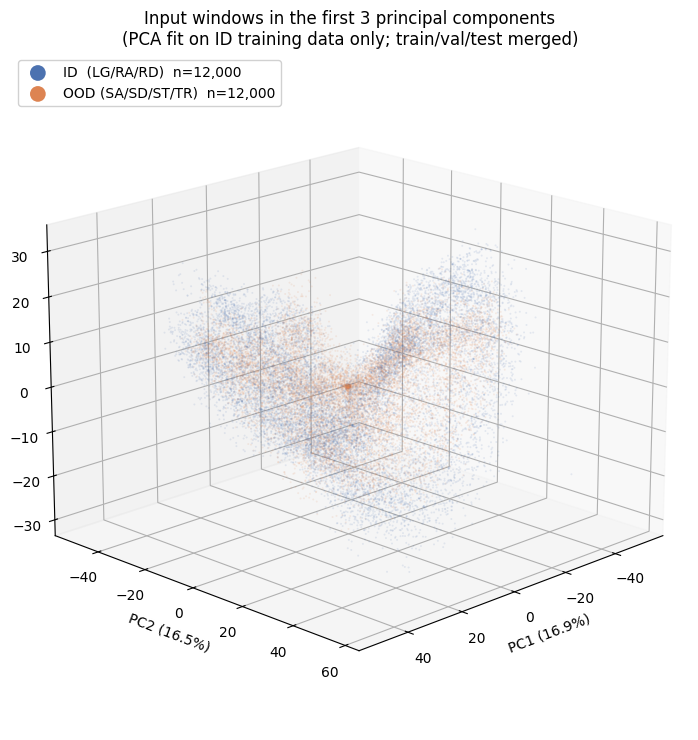

In [4]:
RNG = np.random.default_rng(0)
N_PLOT = 12_000

def sub(a, n=N_PLOT):
    return a[RNG.choice(len(a), size=min(n, len(a)), replace=False)]

id_p, ood_p = sub(ID), sub(OOD)
C_ID, C_OOD = "#4C72B0", "#DD8452"

fig = plt.figure(figsize=(9, 7.5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*id_p.T, s=2, alpha=0.12, c=C_ID, label=f"ID  (LG/RA/RD)  n={len(id_p):,}",
           edgecolors="none", rasterized=True)
ax.scatter(*ood_p.T, s=2, alpha=0.12, c=C_OOD, label=f"OOD (SA/SD/ST/TR)  n={len(ood_p):,}",
           edgecolors="none", rasterized=True)
ax.set_xlabel(f"PC1 ({evr[0]:.1%})"); ax.set_ylabel(f"PC2 ({evr[1]:.1%})")
ax.set_zlabel(f"PC3 ({evr[2]:.1%})")
ax.set_title("Input windows in the first 3 principal components\n"
             "(PCA fit on ID training data only; train/val/test merged)")
leg = ax.legend(loc="upper left", markerscale=8, framealpha=0.9)
for h in leg.legend_handles:
    h.set_alpha(1)
ax.view_init(elev=18, azim=45)
fig.tight_layout()

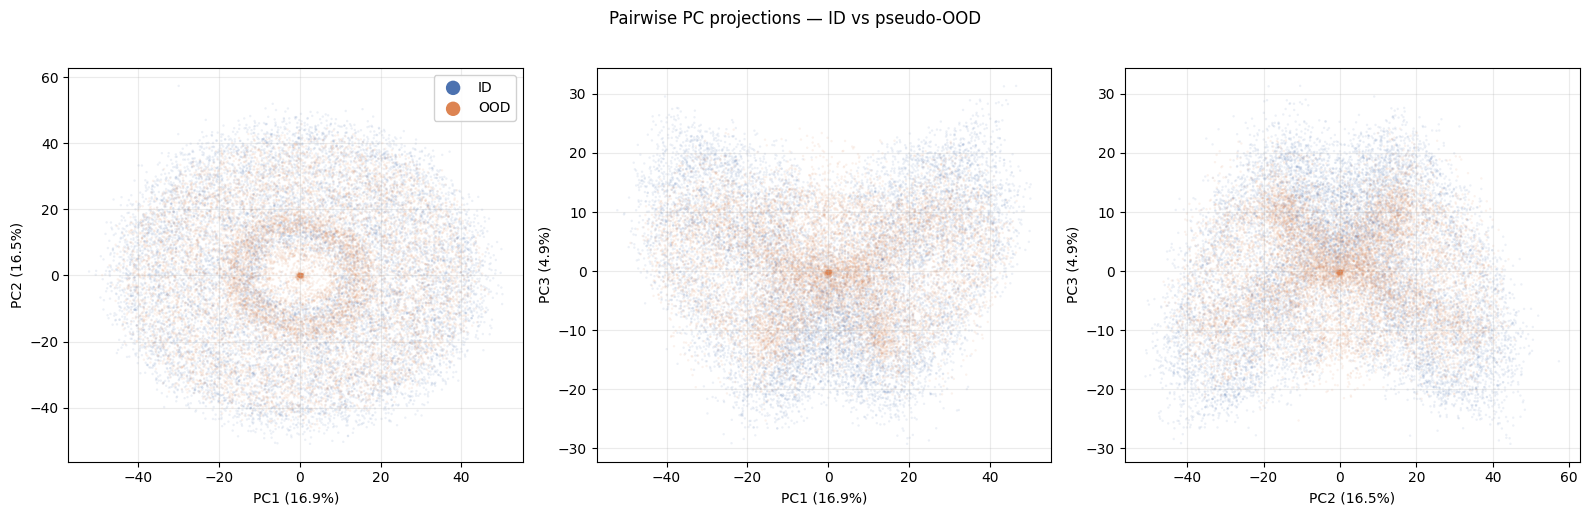

In [5]:
# Pairwise projections -- easier to read overlap than the 3D view
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(id_p[:, i], id_p[:, j], s=3, alpha=0.10, c=C_ID, edgecolors="none",
               label="ID", rasterized=True)
    ax.scatter(ood_p[:, i], ood_p[:, j], s=3, alpha=0.10, c=C_OOD, edgecolors="none",
               label="OOD", rasterized=True)
    ax.set_xlabel(f"PC{i+1} ({evr[i]:.1%})"); ax.set_ylabel(f"PC{j+1} ({evr[j]:.1%})")
    ax.grid(alpha=0.25)
leg = axes[0].legend(markerscale=6, framealpha=0.9)
for h in leg.legend_handles:
    h.set_alpha(1)
fig.suptitle("Pairwise PC projections — ID vs pseudo-OOD", y=1.02)
fig.tight_layout()

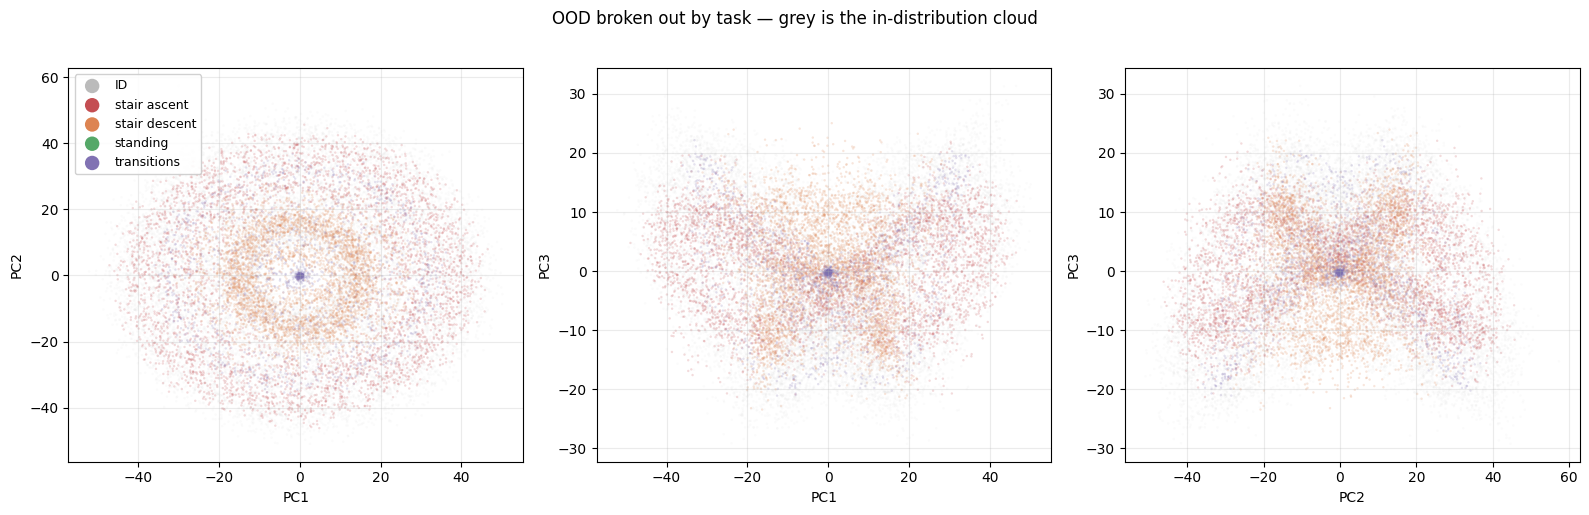

In [6]:
# Which OOD tasks actually leave the ID manifold?
modes = ["SA", "SD", "ST", "TR"]
names = {"SA": "stair ascent", "SD": "stair descent", "ST": "standing", "TR": "transitions"}
cols = {"SA": "#C44E52", "SD": "#DD8452", "ST": "#55A868", "TR": "#8172B3"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(id_p[:, i], id_p[:, j], s=3, alpha=0.06, c="#BBBBBB", edgecolors="none",
               label="ID", rasterized=True)
    for m in modes:
        sel = OOD[ood_modes == m]
        if not len(sel):
            continue
        sel = sub(sel, 4000)
        ax.scatter(sel[:, i], sel[:, j], s=3, alpha=0.20, c=cols[m], edgecolors="none",
                   label=names[m], rasterized=True)
    ax.set_xlabel(f"PC{i+1}"); ax.set_ylabel(f"PC{j+1}"); ax.grid(alpha=0.25)
leg = axes[0].legend(markerscale=6, framealpha=0.9, fontsize=9)
for h in leg.legend_handles:
    h.set_alpha(1)
fig.suptitle("OOD broken out by task — grey is the in-distribution cloud", y=1.02)
fig.tight_layout()

### Is this representation separable at all?

Two linear baselines, both scored the way the paper scores its uncertainty estimates —
threshold at the **99.5th percentile of ID training scores**, then measure recall on OOD and
specificity on ID.

1. **Mahalanobis distance** from the ID training centre in PC1-3.
2. **Local Outlier Factor** on PC1-3 — the *scoring rule* the paper settled on for its
   autoencoder.

Read the result as a floor, not as a verdict on the paper's method. The paper applies LOF to a
**learned 28-dimensional autoencoder latent**; this applies it to 3 linear components holding
38% of the variance. If these succeed, the problem is easy. If they fail, it tells us where the
difficulty lives — which is the useful outcome here.

In [7]:
from sklearn.neighbors import LocalOutlierFactor

Z_tr = Z_id["train"]

# --- baseline 1: distance from the ID centre ---------------------------------
mu, cov = Z_tr.mean(0), np.cov(Z_tr, rowvar=False)
inv = np.linalg.inv(cov)
maha = lambda Z: np.sqrt(np.einsum("ij,jk,ik->i", Z - mu, inv, Z - mu))

# --- baseline 2: LOF, the paper's scoring rule -------------------------------
fit = Z_tr[RNG.choice(len(Z_tr), min(20_000, len(Z_tr)), replace=False)]
lof = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(fit)
lof_score = lambda Z: -lof.score_samples(Z)

results = {}
for label, fn, train_ref in [("Mahalanobis", maha, Z_tr), ("LOF (k=20)", lof_score, fit)]:
    thr = np.percentile(fn(train_ref), 99.5)
    s_id, s_ood = fn(ID), fn(OOD)
    rec, spec = (s_ood > thr).mean(), (s_id <= thr).mean()
    results[label] = {"threshold": round(float(thr), 3),
                      "recall_OOD": f"{rec:.1%}", "specificity_ID": f"{spec:.1%}",
                      "J_statistic": round(float((rec + spec - 1) * 100), 1),
                      **{f"recall_{m}": f"{(s_ood[ood_modes == m] > thr).mean():.1%}"
                         for m in modes if (ood_modes == m).any()}}

display(pd.DataFrame(results).T)
print("\nFor reference, the paper's gait-phase ensemble reached J = 92.3 on genuinely")
print("non-cyclic OOD (sitting, jumping, lying down).")

,threshold,recall_OOD,specificity_ID,J_statistic,recall_SA,recall_SD,recall_ST,recall_TR
Mahalanobis,2.806,0.0%,99.7%,-0.3,0.0%,0.0%,0.0%,0.0%
LOF (k=20),1.391,6.1%,97.8%,3.9,5.8%,7.5%,0.0%,4.7%



For reference, the paper's gait-phase ensemble reached J = 92.3 on genuinely
non-cyclic OOD (sitting, jumping, lying down).


### Why both fail

The per-task spread explains it, and standing is the clearest case.

In [8]:
spread = pd.DataFrame(
    {"ID (LG/RA/RD)": Z_tr.std(0)}
    | {names[m]: OOD[ood_modes == m].std(0) for m in modes if (ood_modes == m).any()},
    index=["PC1", "PC2", "PC3"],
).T.round(2)
spread["dist. of task mean from ID centre"] = [float(np.linalg.norm(Z_tr.mean(0) - mu))] + [
    float(np.linalg.norm(OOD[ood_modes == m].mean(0) - mu)) for m in modes if (ood_modes == m).any()
]
display(spread.round(2))

,PC1,PC2,PC3,dist. of task mean from ID centre
ID (LG/RA/RD),23.29,23.01,12.51,0.00
stair ascent,25.16,23.96,7.76,0.30
stair descent,12.07,11.99,9.01,0.16
standing,0.06,0.06,0.04,0.21
transitions,14.21,14.01,7.62,0.11


Three things fall out of that table:

**Standing collapses to a point at the centre of the walking cloud.** Its spread is ~0.1 in
each component against ~23 for in-distribution walking, and its mean sits essentially *on* the
ID centroid. So the most obviously out-of-distribution task in the set is, by these two
measures, the most normal-looking data we have. Distance-from-centre scores it near zero, and
LOF sees a dense tight cluster sitting in the densest region of the ID distribution and calls
it an inlier.

This is not a surprise — it is the same failure the ankle paper reports, in almost the same
words:

> reconstruction error did not work well as an uncertainty score for our application, likely
> because `D_OOD_val` contains a significant amount of low-complexity stationary data, such as
> standing, which is particularly easy for the model to reconstruct

Reproducing their negative result on hip data, before building anything, is a useful
confirmation that the setup behaves the way theirs did.

**The principal components encode gait-cycle phase, not task identity.** Walking sweeps a wide
orbit in PC1-PC2 (std ≈ 23), so the leading directions describe *where in the stride* a window
sits. Stair ascent has a comparable or larger spread and overlaps that orbit; it is not
displaced from it. Three linear components spend their capacity on the strongest periodic
variation rather than on what makes a task different.

**38% of variance in 3 components is not much.** The plots above are a genuine picture of
PC1-3, but they are a thin slice of a 3200-dimensional space, and the discriminative structure
evidently is not in the top three directions.

None of this says the paper's approach won't work here — it says a linear projection is the
wrong representation, which is precisely the argument for a learned nonlinear one.

**A note toward feature engineering (OBJ 2):** standing is trivially separable by
*within-window variance* — a statistic that is nowhere in PC1-3, because PCA on standardized
windows is a projection of the signal, not of its variability. That is a concrete example of a
cheap engineered feature carrying information the raw representation buries.